In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.features.vectorizer import (
    build_vectorizer,
    fit_transform_texts,
    fit_vectorizer,
    transform_texts,
    save_vectorizer,
    get_top_features_per_class
)
from src.utils.config import (
    PROCESSED_DATA_DIR,
    TEXT_COLUMN,
    CATEGORY_TARGET,
    PRIORITY_TARGET,
    MODELS_DIR
)

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(PROCESSED_DATA_DIR / "tickets_cleaned.csv")

print(f"Loaded {len(df)} cleaned tickets")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSample clean text:")
print(df["clean_text"].iloc[0])

Loaded 8418 cleaned tickets
Columns: ['clean_text', 'Ticket Type', 'Ticket Priority']

Sample clean text:
website address


In [3]:
from src.data.loader import load_raw_data
from src.data.preprocessor import preprocess_dataframe

train_df, test_df = load_raw_data()

train_clean = preprocess_dataframe(train_df)
test_clean  = preprocess_dataframe(test_df)

X_train = train_clean[TEXT_COLUMN]
X_test  = test_clean[TEXT_COLUMN]

y_cat_train = train_clean[CATEGORY_TARGET]
y_cat_test  = test_clean[CATEGORY_TARGET]

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"\nTrain distribution:")
print(y_cat_train.value_counts())

[2026-04-11 09:57:57] INFO — src.data.loader — Loading Zenodo IT Support Ticket dataset...
[2026-04-11 09:57:57] INFO — src.data.loader — Train set: 1572 tickets
[2026-04-11 09:57:57] INFO — src.data.loader — Test set:  657 tickets
[2026-04-11 09:57:57] INFO — src.data.preprocessor — Starting text preprocessing pipeline...
[2026-04-11 09:57:57] INFO — src.data.preprocessor — Dropping rows with missing ticket text...
[2026-04-11 09:57:57] INFO — src.data.preprocessor — Cleaning text column...
[2026-04-11 09:58:00] INFO — src.data.preprocessor — Removing rows where clean text is empty after processing...
[2026-04-11 09:58:00] INFO — src.data.preprocessor — Dropped 1 rows with empty clean text
[2026-04-11 09:58:00] INFO — src.data.preprocessor — Preprocessing complete. 1571 rows remaining.
[2026-04-11 09:58:00] INFO — src.data.preprocessor — Starting text preprocessing pipeline...
[2026-04-11 09:58:00] INFO — src.data.preprocessor — Dropping rows with missing ticket text...
[2026-04-11 09

In [4]:
vectorizer = build_vectorizer()

# Fit ONLY on training data - never on test data
X_train_tfidf = fit_transform_texts(vectorizer, X_train)
X_test_tfidf = transform_texts(vectorizer, X_test)

print(f"\nTraining matrix:  {X_train_tfidf.shape}")
print(f"Test matrix:      {X_test_tfidf.shape}")
print(f"Vocabulary size:  {len(vectorizer.vocabulary_)}")

[2026-04-11 09:58:00] INFO — src.features.vectorizer — Building TF-IDF vectorizer with params:
[2026-04-11 09:58:00] INFO — src.features.vectorizer —   max_features: 5000
[2026-04-11 09:58:00] INFO — src.features.vectorizer —   ngram_range: (1, 2)
[2026-04-11 09:58:00] INFO — src.features.vectorizer —   min_df: 3
[2026-04-11 09:58:00] INFO — src.features.vectorizer —   max_df: 0.7
[2026-04-11 09:58:00] INFO — src.features.vectorizer —   sublinear_tf: True
[2026-04-11 09:58:00] INFO — src.features.vectorizer — Fit-transforming 1571 documents...
[2026-04-11 09:58:00] INFO — src.features.vectorizer — Vocabulary size: 1330
[2026-04-11 09:58:00] INFO — src.features.vectorizer — Feature matrix shape: (1571, 1330)
[2026-04-11 09:58:00] INFO — src.features.vectorizer — Transforming 657 documents...
[2026-04-11 09:58:00] INFO — src.features.vectorizer — Feature matrix shape: (657, 1330)

Training matrix:  (1571, 1330)
Test matrix:      (657, 1330)
Vocabulary size:  1330


In [5]:
feature_names = vectorizer.get_feature_names_out()

print("First 30 features (alphabetical):")
print(feature_names[:30].tolist())

print("\nLast 30 features:")
print(feature_names[-30:].tolist())

# Find some meaningful bigrams
bigrams = [f for f in feature_names if " " in f]
print(f"\nTotal bigrams in vocabulary: {len(bigrams)}")
print(f"Sample bigrams: {bigrams[:20]}")

First 30 features (alphabetical):
['00', '00 location', '00am', '00am additional', '00am important', '00am requestor', '00pm', '00pm important', '01', '01 02', '02', '02 01', '02 2019', '04', '10', '10 10', '10 2019', '11', '11 00pm', '12', '12 00am', '13', '13 2018', '14', '15', '15 2019', '17', '17 2018', '174454', '174454 company']

Last 30 features:
['with name', 'work', 'working', 'would', 'write', 'write file', 'wrong', 'yes', 'yes please', 'yet', 'yet exist', 'you', 'you please', 'your', 'your role', 'zertifikat', 'zip', 'zip address', 'zip city', 'zip location', 'zu', 'zugang', 'zugang bo', 'zugriff', 'zugriff auf', 'zugriffsrechte', 'zum', 'zum erstellen', 'zur', 'zur verfügung']

Total bigrams in vocabulary: 720
Sample bigrams: ['00 location', '00am additional', '00am important', '00am requestor', '00pm important', '01 02', '02 01', '02 2019', '10 10', '10 2019', '11 00pm', '12 00am', '13 2018', '15 2019', '17 2018', '174454 company', '18 2018', '2018 00am', '2018 12', '2019 

In [6]:
top_features = get_top_features_per_class(
    vectorizer,
    X_train_tfidf,
    y_cat_train,
    n=15
)

print("=== TOP 15 WORDS PER CATEGORY ===\n")
for category, words in top_features.items():
    print(f"{category}:")
    print(f"  {', '.join(words)}")
    print()

=== TOP 15 WORDS PER CATEGORY ===

Fileservice:
  file, share, file share, share access, access ticket, id name, name company, access, company location, name, company, location, ticket id, id, ticket

Support general:
  email, mailbox, shared mailbox, shared, mailbox access, ticket, support, support ticket, access, id, ticket id, new, id new, received, ticket received

Software:
  on, missing, server, connection to, missing connection, connection, on system, initiated by, initiated, to, system server, by, ticket, support ticket, support

EOL:
  reservations, if, remove, and, nexthink, please remove, location reservations, any, the, please, system, to, life in, in nexthink, be set

O365:
  ticket, support ticket, support, received, ticket received, new support, id new, new, skype, id, ticket id, email, to, id support, forwarded to

Active Directory:
  user, ad, new, support, ticket, support ticket, name, löschen, ticket received, new support, received, id new, change, id, to

Computer-S

In [7]:
# How many tickets contain the phrase "please assist"?
count = df["clean_text"].str.contains("please assist").sum()
print(f"Tickets containing 'please assist': {count} / {len(df)}")
print(f"Percentage: {count/len(df)*100:.1f}%")

Tickets containing 'please assist': 0 / 8418
Percentage: 0.0%


In [8]:
# Look at 10 raw tickets side by side to spot the template
pd.set_option('display.max_colwidth', 500)
df_raw_check = pd.read_csv("../data/raw/customer_support_tickets.csv")
print(df_raw_check["Ticket Description"].head(10).to_string())

0                                                         I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciate that you have requested a website address.\n\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.
1                                                           I'm having an issue with the {product_purchased}. Please assist.\n\nIf you need to change an existing product.\n\nI'm having an issue with the {product_purchased}. Please assist.\n\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.
2                                                                      I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\n\n1.8.3 I really I'm using the original charger that came with my {produ

IndexError: list index out of range

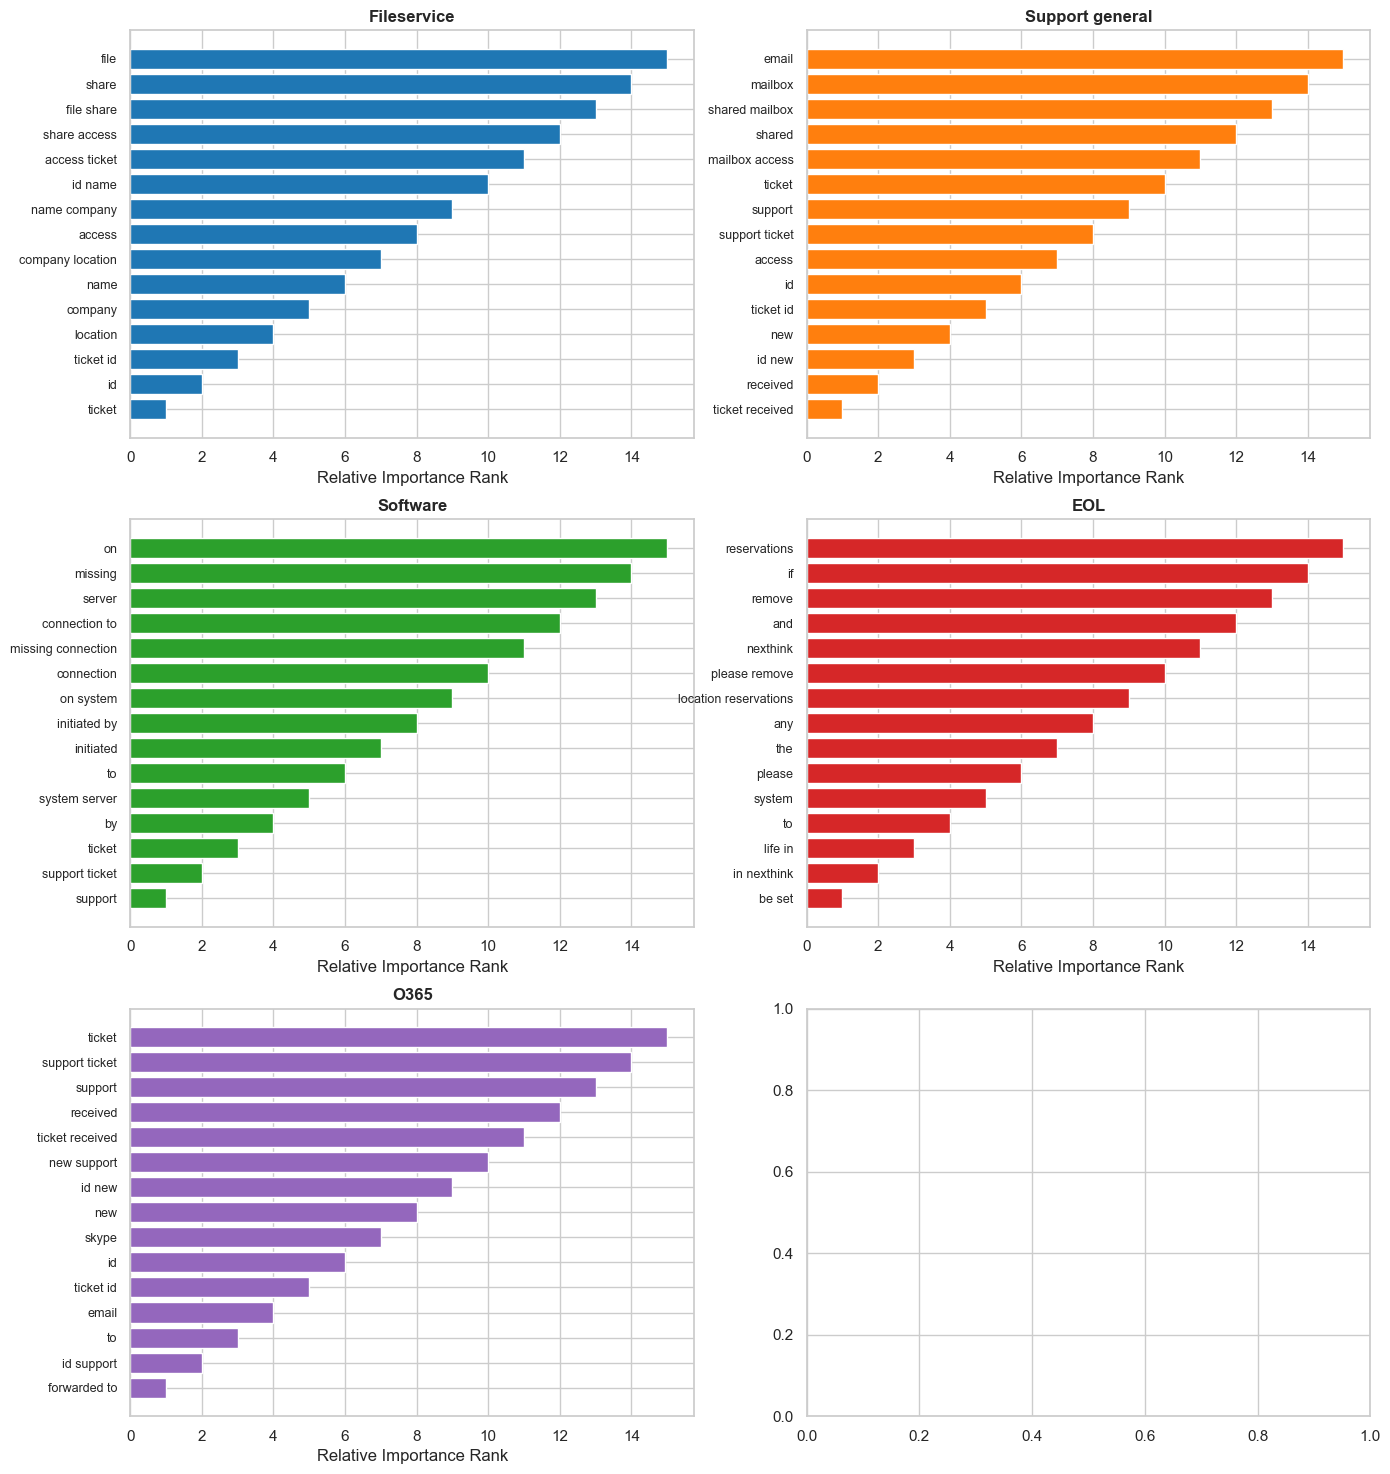

In [9]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 18)
)
axes = axes.flatten()

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for idx, (category, words) in enumerate(top_features.items()):
    ax = axes[idx]
    scores = list(range(len(words), 0, -1))

    ax.barh(words[::-1], scores[::-1], color=colors[idx])
    ax.set_title(f"{category}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Relative Importance Rank")
    ax.tick_params(axis="y", labelsize=9)

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle(
    "Top 15 TF-IDF Features Per Category",
    fontsize=15,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.savefig("../outputs/figures/top_features_per_category.png", dpi=150)
plt.show()

In [ ]:
total_elements = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
non_zero = X_train_tfidf.nnz
sparsity = (1 - non_zero / total_elements) * 100

print(f"Matrix shape:     {X_train_tfidf.shape}")
print(f"Total elements:   {total_elements:,}")
print(f"Non-zero elements:{non_zero:,}")
print(f"Sparsity:         {sparsity:.1f}%")

Matrix shape:     (6734, 4342)
Total elements:   29,239,028
Non-zero elements:187,920
Sparsity:         99.4%


In [ ]:
from src.features.vectorizer import save_vectorizer
import joblib

# Save the fitted vectorizer
save_vectorizer(vectorizer, "tfidf_vectorizer.pkl")

# Save the train/test splits for Sprint 4 and 5
splits = {
    "X_train": X_train,
    "X_test": X_test,
    "X_train_tfidf": X_train_tfidf,
    "X_test_tfidf": X_test_tfidf,
    "y_cat_train": y_cat_train,
    "y_cat_test": y_cat_test,
    "y_priority_train": df.loc[X_train.index, PRIORITY_TARGET],
    "y_priority_test": df.loc[X_test.index, PRIORITY_TARGET],
}

joblib.dump(splits, MODELS_DIR / "train_test_splits.pkl")
print("Vectorizer and splits saved successfully")
print(f"Splits saved to: {MODELS_DIR / 'train_test_splits.pkl'}")

[2026-04-11 09:03:19] INFO — src.features.vectorizer — Vectorizer saved to E:\Future ml projects\FUTURE_ML_02\outputs\models\tfidf_vectorizer.pkl
Vectorizer and splits saved successfully
Splits saved to: E:\Future ml projects\FUTURE_ML_02\outputs\models\train_test_splits.pkl
